<a href="https://colab.research.google.com/github/rongxie2023/dlcv/blob/main/Chapter05/03-迁移学习微调训练-基础版.ipynb" target="_blank"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 迁移学习微调训练图像分类模型

在自己的图像分类数据集上，使用ImageNet预训练图像分类模型初始化，改动分类层，迁移学习微调训练

同济子豪兄：https://space.bilibili.com/1900783

[代码运行云GPU环境](https://featurize.cn/?s=d7ce99f842414bfcaea5662a97581bd1)：GPU RTX 3060、CUDA v11.2

## 导入工具包

In [1]:
import time
import os

import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
%matplotlib inline

# 忽略烦人的红色提示
import warnings
warnings.filterwarnings("ignore")

import matplotlib
import matplotlib.pyplot as plt
matplotlib.rc("font",family='SimHei') # 中文字体
plt.rcParams['axes.unicode_minus']=False  # 用来正常显示负号


## 获取计算硬件

In [2]:
# 有 GPU 就用 GPU，没有就用 CPU
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print('device', device)

device cuda:0


## 图像预处理

In [3]:
from torchvision import transforms

# 训练集图像预处理：缩放裁剪、图像增强、转 Tensor、归一化
train_transform = transforms.Compose([transforms.RandomResizedCrop(224),
                                      transforms.RandomHorizontalFlip(),
                                      transforms.ToTensor(),
                                      transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
                                     ])

# 测试集图像预处理-RCTN：缩放、裁剪、转 Tensor、归一化
test_transform = transforms.Compose([transforms.Resize(256),
                                     transforms.CenterCrop(224),
                                     transforms.ToTensor(),
                                     transforms.Normalize(
                                         mean=[0.485, 0.456, 0.406], 
                                         std=[0.229, 0.224, 0.225])
                                    ])

## 载入图像分类数据集

In [4]:
# 数据集文件夹路径
dataset_dir = '../datasets/fruit30_split'
train_path = os.path.join(dataset_dir, 'train')
test_path = os.path.join(dataset_dir, 'val')
print('训练集路径', train_path)
print('测试集路径', test_path)

训练集路径 ../datasets/fruit30_split/train
测试集路径 ../datasets/fruit30_split/val


In [5]:
from torchvision import datasets

# 载入训练集
train_dataset = datasets.ImageFolder(train_path, train_transform)

# 载入测试集
test_dataset = datasets.ImageFolder(test_path, test_transform)

In [6]:
print('训练集图像数量', len(train_dataset))
print('类别个数', len(train_dataset.classes))
print('各类别名称', train_dataset.classes)

训练集图像数量 4375
类别个数 30
各类别名称 ['哈密瓜', '圣女果', '山竹', '杨梅', '柚子', '柠檬', '桂圆', '梨', '椰子', '榴莲', '火龙果', '猕猴桃', '石榴', '砂糖橘', '胡萝卜', '脐橙', '芒果', '苦瓜', '苹果-红', '苹果-青', '草莓', '荔枝', '菠萝', '葡萄-白', '葡萄-红', '西瓜', '西红柿', '车厘子', '香蕉', '黄瓜']


In [7]:
print('测试集图像数量', len(test_dataset))
print('类别个数', len(test_dataset.classes))
print('各类别名称', test_dataset.classes)

测试集图像数量 1078
类别个数 30
各类别名称 ['哈密瓜', '圣女果', '山竹', '杨梅', '柚子', '柠檬', '桂圆', '梨', '椰子', '榴莲', '火龙果', '猕猴桃', '石榴', '砂糖橘', '胡萝卜', '脐橙', '芒果', '苦瓜', '苹果-红', '苹果-青', '草莓', '荔枝', '菠萝', '葡萄-白', '葡萄-红', '西瓜', '西红柿', '车厘子', '香蕉', '黄瓜']


## 类别和索引号 一一对应

In [8]:
# 各类别名称
class_names = train_dataset.classes
n_class = len(class_names)

In [9]:
class_names

['哈密瓜',
 '圣女果',
 '山竹',
 '杨梅',
 '柚子',
 '柠檬',
 '桂圆',
 '梨',
 '椰子',
 '榴莲',
 '火龙果',
 '猕猴桃',
 '石榴',
 '砂糖橘',
 '胡萝卜',
 '脐橙',
 '芒果',
 '苦瓜',
 '苹果-红',
 '苹果-青',
 '草莓',
 '荔枝',
 '菠萝',
 '葡萄-白',
 '葡萄-红',
 '西瓜',
 '西红柿',
 '车厘子',
 '香蕉',
 '黄瓜']

In [10]:
# 映射关系：类别 到 索引号
train_dataset.class_to_idx

{'哈密瓜': 0,
 '圣女果': 1,
 '山竹': 2,
 '杨梅': 3,
 '柚子': 4,
 '柠檬': 5,
 '桂圆': 6,
 '梨': 7,
 '椰子': 8,
 '榴莲': 9,
 '火龙果': 10,
 '猕猴桃': 11,
 '石榴': 12,
 '砂糖橘': 13,
 '胡萝卜': 14,
 '脐橙': 15,
 '芒果': 16,
 '苦瓜': 17,
 '苹果-红': 18,
 '苹果-青': 19,
 '草莓': 20,
 '荔枝': 21,
 '菠萝': 22,
 '葡萄-白': 23,
 '葡萄-红': 24,
 '西瓜': 25,
 '西红柿': 26,
 '车厘子': 27,
 '香蕉': 28,
 '黄瓜': 29}

In [11]:
# 映射关系：索引号 到 类别
idx_to_labels = {y:x for x,y in train_dataset.class_to_idx.items()}

In [12]:
idx_to_labels

{0: '哈密瓜',
 1: '圣女果',
 2: '山竹',
 3: '杨梅',
 4: '柚子',
 5: '柠檬',
 6: '桂圆',
 7: '梨',
 8: '椰子',
 9: '榴莲',
 10: '火龙果',
 11: '猕猴桃',
 12: '石榴',
 13: '砂糖橘',
 14: '胡萝卜',
 15: '脐橙',
 16: '芒果',
 17: '苦瓜',
 18: '苹果-红',
 19: '苹果-青',
 20: '草莓',
 21: '荔枝',
 22: '菠萝',
 23: '葡萄-白',
 24: '葡萄-红',
 25: '西瓜',
 26: '西红柿',
 27: '车厘子',
 28: '香蕉',
 29: '黄瓜'}

In [13]:
# 保存为本地的 npy 文件
np.save('idx_to_labels.npy', idx_to_labels)
np.save('labels_to_idx.npy', train_dataset.class_to_idx)

## 定义数据加载器DataLoader

In [14]:
from torch.utils.data import DataLoader

In [15]:
BATCH_SIZE = 32

# 训练集的数据加载器
train_loader = DataLoader(train_dataset,
                          batch_size=BATCH_SIZE,
                          shuffle=True,
                          num_workers=4
                         )

# 测试集的数据加载器
test_loader = DataLoader(test_dataset,
                         batch_size=BATCH_SIZE,
                         shuffle=False,
                         num_workers=4
                        )

## 查看一个batch的图像和标注

In [16]:
# DataLoader 是 python生成器，每次调用返回一个 batch 的数据
images, labels = next(iter(train_loader))

In [17]:
images.shape

torch.Size([32, 3, 224, 224])

In [18]:
labels

tensor([15, 20, 14, 18,  4, 19,  4,  3, 23, 12, 23,  7,  6, 12, 13, 11,  6,  4,
        24, 19,  5,  2, 21, 12, 11,  0, 24, 28,  3, 25, 20,  0])

## 可视化一个batch的图像和标注

In [19]:
# 将数据集中的Tensor张量转为numpy的array数据类型
images = images.numpy()

In [20]:
images[5].shape

(3, 224, 224)

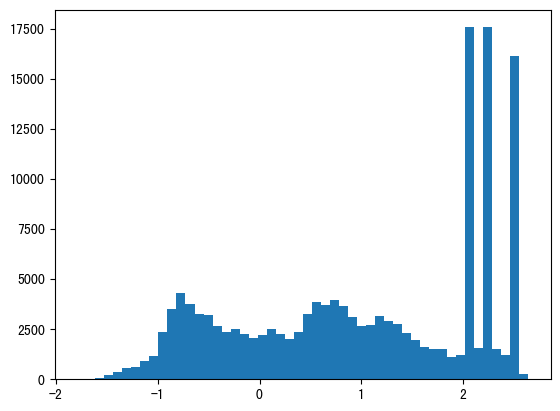

In [21]:
plt.hist(images[5].flatten(), bins=50)
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5081482..2.64].


Text(0.5, 1.0, 'label:14')

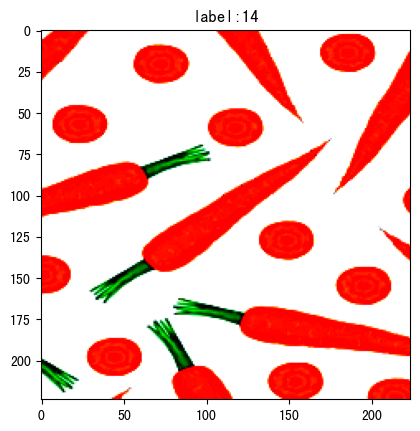

In [22]:
# batch 中经过预处理的图像
idx = 2
plt.imshow(images[idx].transpose((1,2,0))) # 转为(224, 224, 3)
plt.title('label:'+str(labels[idx].item()))

In [23]:
label = labels[idx].item()

In [24]:
label

14

In [25]:
pred_classname = idx_to_labels[label]

In [26]:
pred_classname

'胡萝卜'

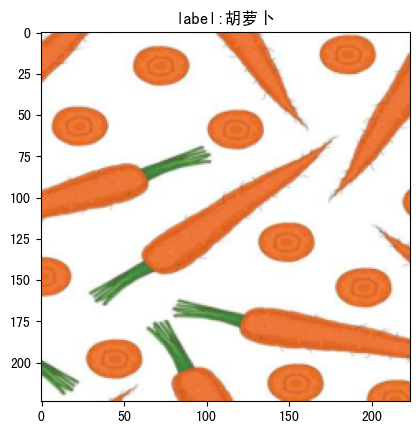

In [27]:
# 原始图像
idx = 2
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
plt.imshow(np.clip(images[idx].transpose((1,2,0)) * std + mean, 0, 1))
plt.title('label:'+ pred_classname)
plt.show()

## 导入训练需使用的工具包

In [28]:
from torchvision import models
import torch.optim as optim
from torch.optim import lr_scheduler

## 选择迁移学习训练方式

斯坦福CS231N【迁移学习】中文精讲：https://www.bilibili.com/video/BV1K7411W7So

斯坦福CS231N【迁移学习】官方笔记：https://cs231n.github.io/transfer-learning

ResNet算法精讲与论文逐句精读：https://www.bilibili.com/video/BV1vb4y1k7BV

### 选择一：只微调训练模型最后一层（全连接分类层）

In [29]:
model1 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
# model1 = models.resnet18(pretrained=True) # 载入预训练模型

# 1. 查看模型各层名称和是否需要梯度
# for name, param in model1.named_parameters():
#     if param.requires_grad:
#         print(name)

# 2. 修改全连接层，使得全连接层的输出与当前数据集类别数对应
# 新建的层默认 requires_grad=True
model1.fc = nn.Linear(model1.fc.in_features, n_class)

# 3. 只微调训练最后一层全连接层的参数，其它层冻结
for param in model1.parameters():
    param.requires_grad = False
# 只微调最后一层全连接层的参数
for param in model1.fc.parameters():
    param.requires_grad = True

optimizer1 = optim.Adam(model1.fc.parameters())

In [30]:
model1.fc

Linear(in_features=512, out_features=30, bias=True)

### 选择二：微调训练所有层

In [31]:
model2 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

model2.fc = nn.Linear(model2.fc.in_features, n_class)

optimizer2 = optim.Adam(model2.parameters())

### 选择三：随机初始化模型全部权重，从头训练所有层

In [32]:
model3 = models.resnet18() # 只载入模型结构，不载入预训练权重参数

model3.fc = nn.Linear(model3.fc.in_features, n_class)

optimizer3 = optim.Adam(model3.parameters())

## 参考文档

https://pytorch.org/tutorials/beginner/transfer_learning_tutorial.html

https://www.bilibili.com/video/BV1qe4y1D7zD

https://www.bilibili.com/video/BV14J411X7Bb

https://www.bilibili.com/video/BV1w4411u7ay

In [33]:
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

In [34]:
def train_one_batch(model,criterion,optimizer,epoch,batch_idx,images, labels):
    '''
    运行一个 batch 的训练，返回当前 batch 的训练日志
    '''
    
    # 获得一个 batch 的数据和标注
    images = images.to(device)
    labels = labels.to(device)
    
    outputs = model(images) # 输入模型，执行前向预测
    loss = criterion(outputs, labels) # 计算当前 batch 中，每个样本的平均交叉熵损失函数值
    
    # 优化更新权重
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    # 获取当前 batch 的标签类别和预测类别
    _, preds = torch.max(outputs, 1) # 获得当前 batch 所有图像的预测类别
    preds = preds.cpu().numpy()
    loss = loss.detach().cpu().numpy()
    outputs = outputs.detach().cpu().numpy()
    labels = labels.detach().cpu().numpy()
    
    log_train = {}
    log_train['epoch'] = epoch
    log_train['batch'] = batch_idx
    # 计算分类评估指标
    log_train['train_loss'] = loss
    log_train['train_accuracy'] = accuracy_score(labels, preds)
    # log_train['train_precision'] = precision_score(labels, preds, average='macro')
    # log_train['train_recall'] = recall_score(labels, preds, average='macro')
    # log_train['train_f1-score'] = f1_score(labels, preds, average='macro')
    
    return log_train


In [35]:
def evaluate_testset(model,criterion,epoch,loader,device):
    '''
    在整个测试集上评估，返回分类评估指标日志
    '''

    loss_list = []
    labels_list = []
    preds_list = []
    
    with torch.no_grad():
        for images, labels in loader: # 生成一个 batch 的数据和标注
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images) # 输入模型，执行前向预测

            # 获取整个测试集的标签类别和预测类别
            _, preds = torch.max(outputs, 1) # 获得当前 batch 所有图像的预测类别
            preds = preds.cpu().numpy()
            loss = criterion(outputs, labels) # 由 logit，计算当前 batch 中，每个样本的平均交叉熵损失函数值
            loss = loss.detach().cpu().numpy()
            outputs = outputs.detach().cpu().numpy()
            labels = labels.detach().cpu().numpy()

            loss_list.append(loss)
            labels_list.extend(labels)
            preds_list.extend(preds)
        
    log_test = {}
    log_test['epoch'] = epoch
    
    # 计算分类评估指标
    log_test['test_loss'] = np.mean(loss_list)
    log_test['test_accuracy'] = accuracy_score(labels_list, preds_list)
    log_test['test_precision'] = precision_score(labels_list, preds_list, average='macro')
    log_test['test_recall'] = recall_score(labels_list, preds_list, average='macro')
    log_test['test_f1-score'] = f1_score(labels_list, preds_list, average='macro')
    
    return log_test


In [36]:
def train(model, train_loader, test_loader,optimizer,device,name="model1"):
    model = model.to(device)

    # 交叉熵损失函数
    criterion = nn.CrossEntropyLoss() 
    # 训练轮次 Epoch
    EPOCHS = 30
    # 学习率降低策略
    scheduler = lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

    epoch = 0
    batch_idx = 0
    best_test_accuracy = 0

    df_train_log = []
    df_test_log = []
    
    for epoch in range(1, EPOCHS+1):
        
        print(f'Epoch {epoch}/{EPOCHS}')
        
        ## 训练阶段
        model.train()
        for images, labels in tqdm(train_loader): # 获得一个 batch 的数据和标注
            batch_idx += 1
            log_train = train_one_batch(model,criterion,optimizer,epoch,batch_idx,images, labels)
            df_train_log.append(log_train)
            # wandb.log(log_train)
            
        scheduler.step()

        ## 测试阶段
        model.eval()
        log_test = evaluate_testset(model,criterion,epoch,test_loader,device)
        df_test_log.append(log_test)
        # wandb.log(log_test)
        
        # 保存最新的最佳模型文件
        if log_test['test_accuracy'] > best_test_accuracy: 
            # 删除旧的最佳模型文件(如有)
            old_best_checkpoint_path = 'checkpoint/best-{:.3f}.pth'.format(best_test_accuracy)
            if os.path.exists(old_best_checkpoint_path):
                os.remove(old_best_checkpoint_path)
            # 保存新的最佳模型文件
            best_test_accuracy = log_test['test_accuracy']
            new_best_checkpoint_path = 'checkpoint/best-{:.3f}.pth'.format(log_test['test_accuracy'])
            torch.save(model, new_best_checkpoint_path)
            print('保存新的最佳模型', 'checkpoint/best-{:.3f}.pth'.format(best_test_accuracy))
            # best_test_accuracy = log_test['test_accuracy']

    df_train_log=pd.DataFrame(df_train_log)
    df_test_log=pd.DataFrame(df_test_log)
    df_train_log.to_csv(f'训练日志-训练集{name}.csv', index=False)
    df_test_log.to_csv(f'训练日志-测试集{name}.csv', index=False)


In [37]:
train(model1,train_loader,test_loader,optimizer1,device,"model1")
train(model2,train_loader,test_loader,optimizer2,device,"model2")
train(model3,train_loader,test_loader,optimizer3,device,"model3")




Epoch 1/30


100%|██████████| 137/137 [00:05<00:00, 24.78it/s]


保存新的最佳模型 checkpoint/best-0.744.pth
Epoch 2/30


100%|██████████| 137/137 [00:05<00:00, 26.42it/s]


保存新的最佳模型 checkpoint/best-0.802.pth
Epoch 3/30


...

Epoch 29/30


100%|██████████| 137/137 [00:05<00:00, 24.38it/s]


保存新的最佳模型 checkpoint/best-0.650.pth
Epoch 30/30


100%|██████████| 137/137 [00:05<00:00, 26.18it/s]


保存新的最佳模型 checkpoint/best-0.666.pth


In [38]:
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline

df_train1 = pd.read_csv('训练日志-训练集model1.csv')
df_test1 = pd.read_csv('训练日志-测试集model1.csv')
df_train2 = pd.read_csv('训练日志-训练集model2.csv')
df_test2 = pd.read_csv('训练日志-测试集model2.csv')
df_train3 = pd.read_csv('训练日志-训练集model3.csv')
df_test3 = pd.read_csv('训练日志-测试集model3.csv')



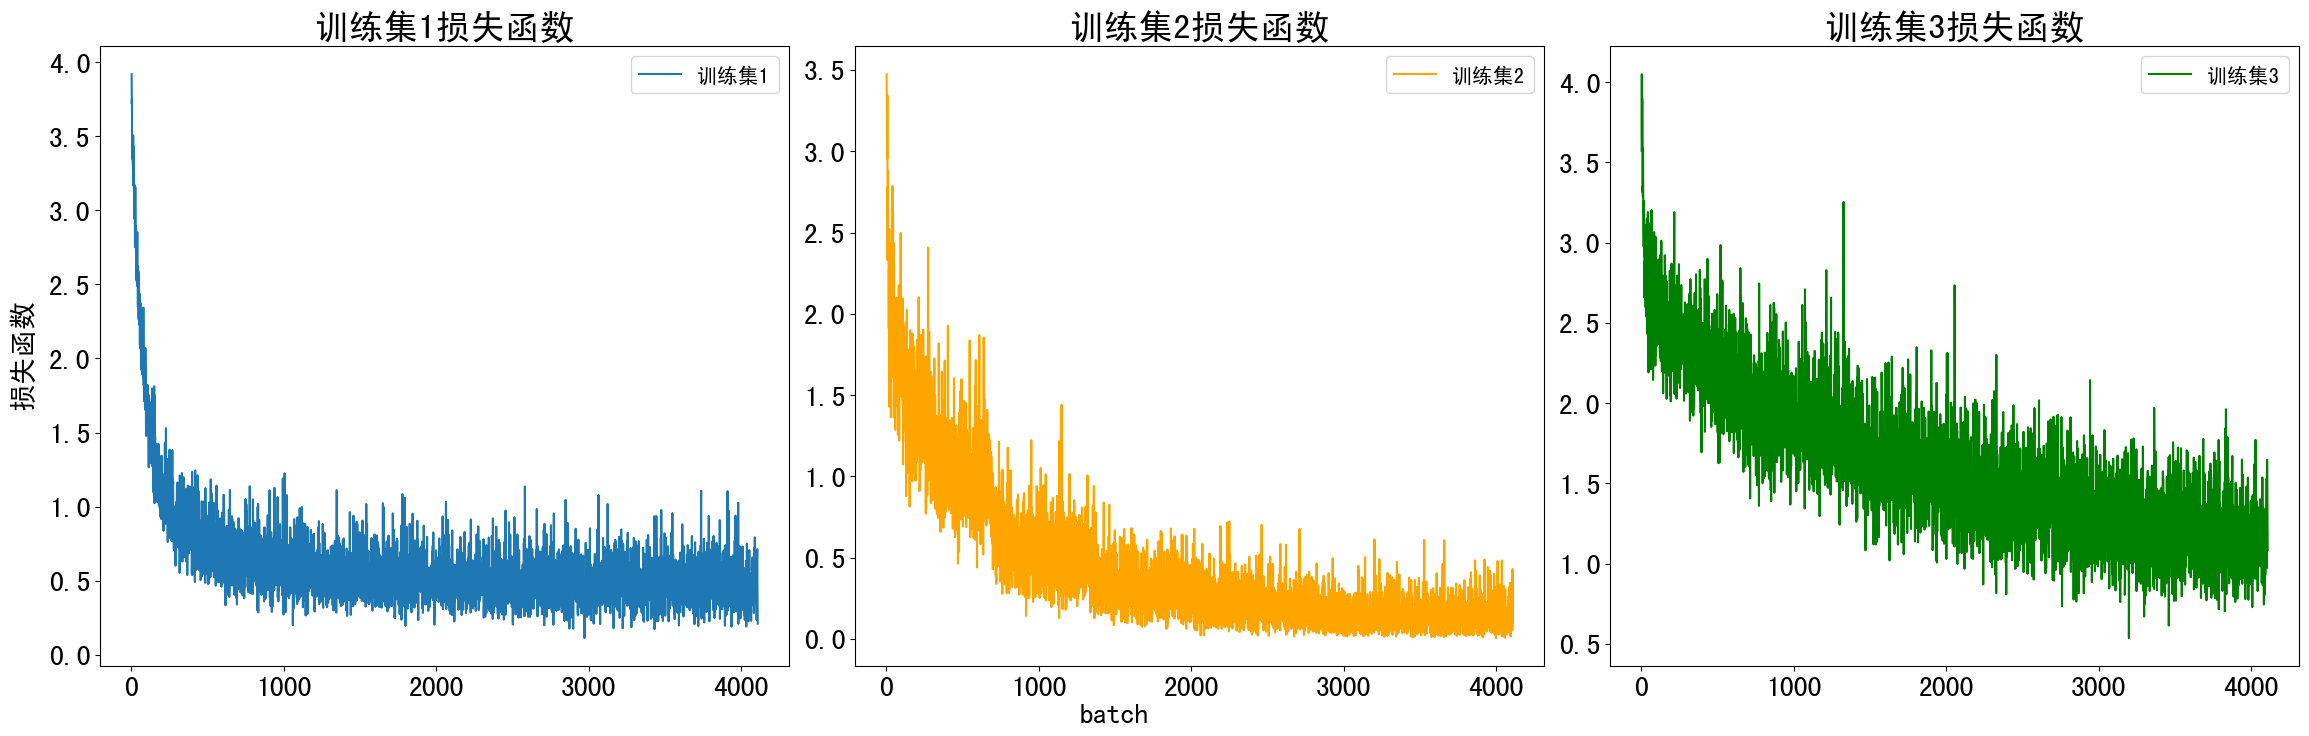

In [41]:
fig, axs = plt.subplots(1, 3, figsize=(24, 8), sharex=True)

# Plotting df_train1 in the first subplot
axs[0].plot(df_train1['batch'], df_train1['train_loss'], label='训练集1')
axs[0].set_title('训练集1损失函数', fontsize=25)
axs[0].tick_params(labelsize=20)
axs[0].legend(fontsize=15)

# Plotting df_train2 in the second subplot
axs[1].plot(df_train2['batch'], df_train2['train_loss'], color='orange', label='训练集2')
axs[1].set_title('训练集2损失函数', fontsize=25)
axs[1].tick_params(labelsize=20)
axs[1].legend(fontsize=15)

# Plotting df_train3 in the third subplot
axs[2].plot(df_train3['batch'], df_train3['train_loss'], color='green', label='训练集3')
axs[2].set_title('训练集3损失函数', fontsize=25)
axs[2].tick_params(labelsize=20)
axs[2].legend(fontsize=15)

# Setting common labels
fig.text(0.5, 0.04, 'batch', ha='center', fontsize=20) # x-axis label shared by all subplots
fig.text(0.04, 0.5, '损失函数', va='center', rotation='vertical', fontsize=20) # y-axis label shared by all subplots

# Adjusting layout to prevent overlap
plt.tight_layout(rect=[0.05, 0.05, 1, 0.95])

# Saving the figure with a new filename to avoid overwriting
plt.savefig('多个训练集的损失函数_subplots.pdf', dpi=120, bbox_inches='tight')

plt.show()

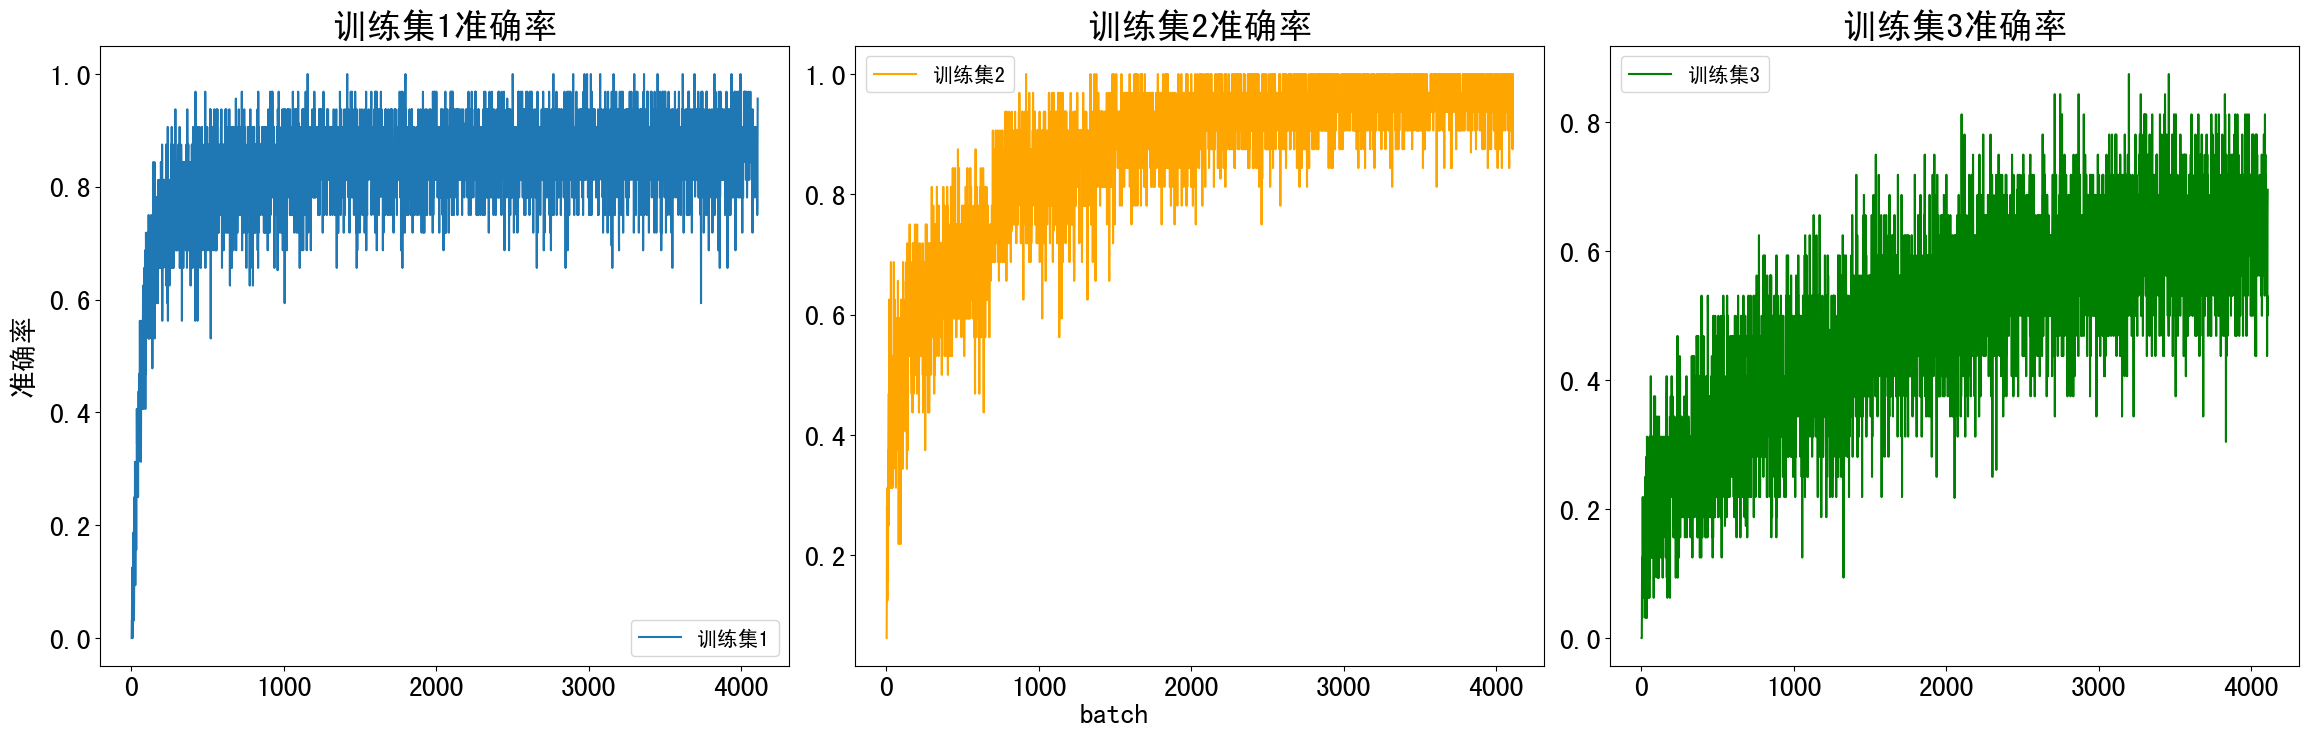

In [42]:
fig, axs = plt.subplots(1, 3, figsize=(24, 8), sharex=True)

# Plotting df_train1 in the first subplot
axs[0].plot(df_train1['batch'], df_train1['train_accuracy'], label='训练集1')
axs[0].set_title('训练集1准确率', fontsize=25)
axs[0].tick_params(labelsize=20)
axs[0].legend(fontsize=15)

# Plotting df_train2 in the second subplot
axs[1].plot(df_train2['batch'], df_train2['train_accuracy'], color='orange', label='训练集2')
axs[1].set_title('训练集2准确率', fontsize=25)
axs[1].tick_params(labelsize=20)
axs[1].legend(fontsize=15)

# Plotting df_train3 in the third subplot
axs[2].plot(df_train3['batch'], df_train3['train_accuracy'], color='green', label='训练集3')
axs[2].set_title('训练集3准确率', fontsize=25)
axs[2].tick_params(labelsize=20)
axs[2].legend(fontsize=15)

# Setting common labels
fig.text(0.5, 0.04, 'batch', ha='center', fontsize=20) # x-axis label shared by all subplots
fig.text(0.04, 0.5, '准确率', va='center', rotation='vertical', fontsize=20) # y-axis label shared by all subplots

# Adjusting layout to prevent overlap
plt.tight_layout(rect=[0.05, 0.05, 1, 0.95])

# Saving the figure with a new filename to avoid overwriting
plt.savefig('多个训练集的准确率_subplots.pdf', dpi=120, bbox_inches='tight')

plt.show()

In [43]:
import random
random.seed(124)
colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k', 'tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown', 'tab:pink', 'tab:gray', 'tab:olive', 'tab:cyan', 'black', 'indianred', 'brown', 'firebrick', 'maroon', 'darkred', 'red', 'sienna', 'chocolate', 'yellow', 'olivedrab', 'yellowgreen', 'darkolivegreen', 'forestgreen', 'limegreen', 'darkgreen', 'green', 'lime', 'seagreen', 'mediumseagreen', 'darkslategray', 'darkslategrey', 'teal', 'darkcyan', 'dodgerblue', 'navy', 'darkblue', 'mediumblue', 'blue', 'slateblue', 'darkslateblue', 'mediumslateblue', 'mediumpurple', 'rebeccapurple', 'blueviolet', 'indigo', 'darkorchid', 'darkviolet', 'mediumorchid', 'purple', 'darkmagenta', 'fuchsia', 'magenta', 'orchid', 'mediumvioletred', 'deeppink', 'hotpink']
markers = [".",",","o","v","^","<",">","1","2","3","4","8","s","p","P","*","h","H","+","x","X","D","d","|","_",0,1,2,3,4,5,6,7,8,9,10,11]
linestyle = ['--', '-.', '-']
def get_line_arg():
    '''
    随机产生一种绘图线型
    '''
    line_arg = {}
    line_arg['color'] = random.choice(colors)
    # line_arg['marker'] = random.choice(markers)
    line_arg['linestyle'] = random.choice(linestyle)
    line_arg['linewidth'] = random.randint(1, 4)
    # line_arg['markersize'] = random.randint(3, 5)
    return line_arg

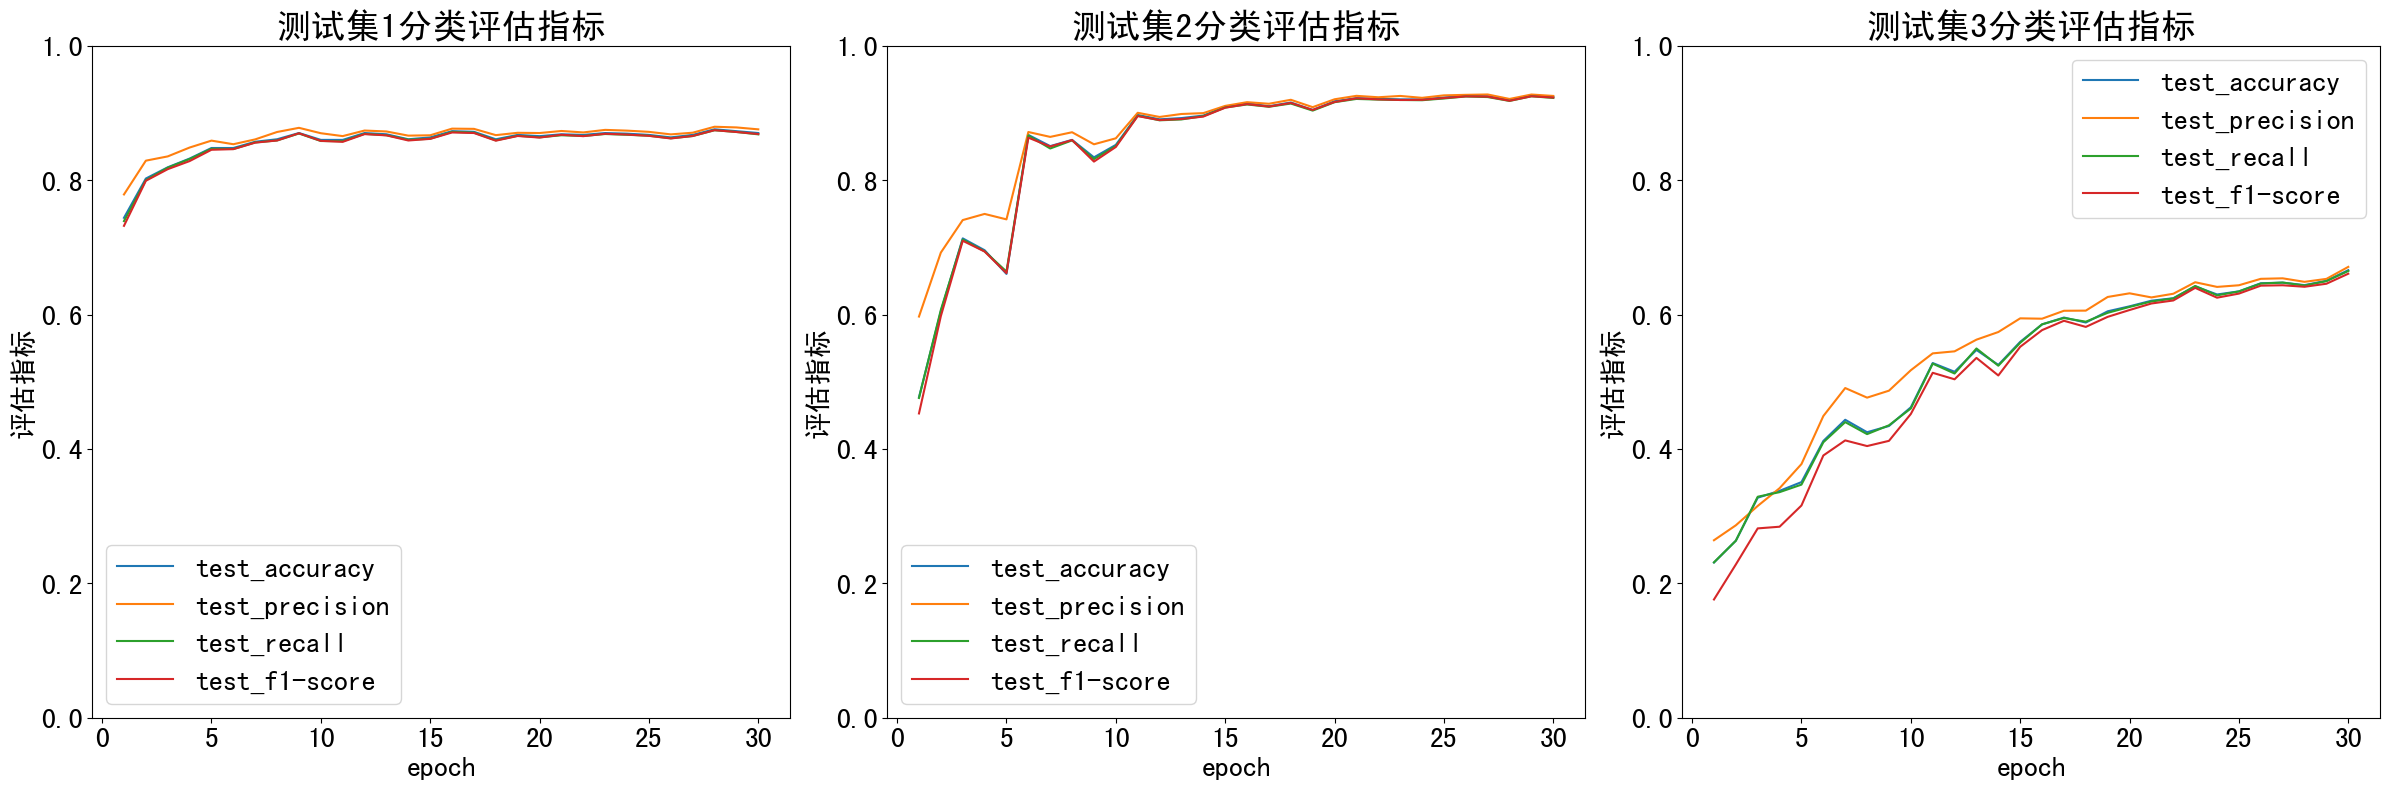

In [47]:
import matplotlib.pyplot as plt

metrics = ['test_accuracy', 'test_precision', 'test_recall', 'test_f1-score']
# Assuming df_test1, df_test2, and df_test3 are pandas DataFrames
data_frames = [df_test1, df_test2, df_test3]
titles = ['测试集1分类评估指标', '测试集2分类评估指标', '测试集3分类评估指标']
file_name = '测试集分类评估指标.pdf'

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(24, 8)) # Create a figure and a set of subplots.

for idx, df in enumerate(data_frames):
    x = df['epoch']
    for y in metrics:
        axes[idx].plot(x, df[y], label=y) # Assuming get_line_arg() returns a dict with plot arguments.
    
    axes[idx].tick_params(labelsize=20)
    axes[idx].set_ylim([0, 1])
    axes[idx].set_xlabel('epoch', fontsize=20)
    axes[idx].set_ylabel('评估指标', fontsize=20)
    axes[idx].set_title(titles[idx], fontsize=25)
    axes[idx].legend(fontsize=20)

plt.tight_layout() # Adjust the layout to ensure everything fits without overlap.
plt.savefig(file_name, dpi=120, bbox_inches='tight') # Save the figure before showing it.
plt.show()